In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm

import warnings
warnings.simplefilter("ignore")

In [2]:
# Load Data
df = pd.read_csv("census.csv")
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [4]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


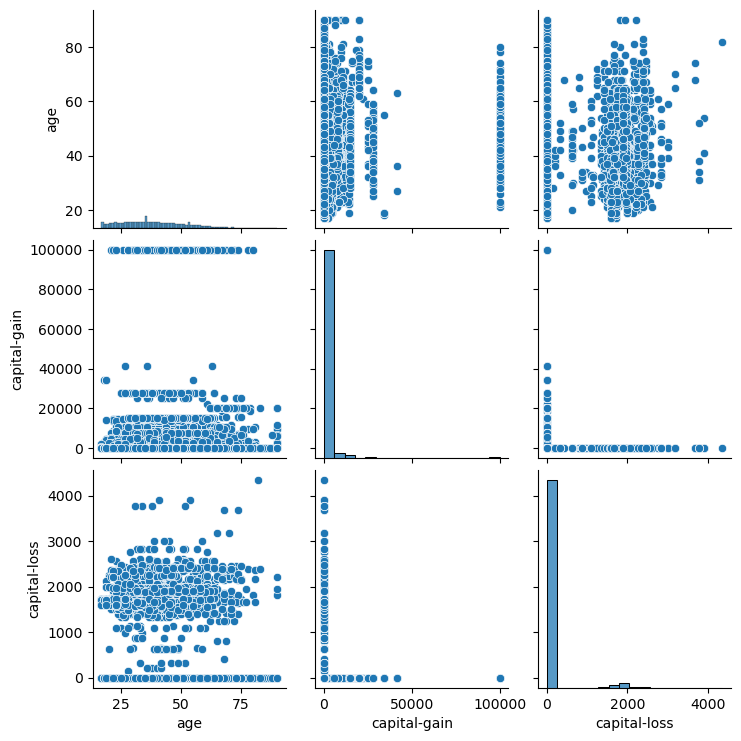

In [5]:
fig = sns.pairplot(df[['age','capital-gain','capital-loss']])

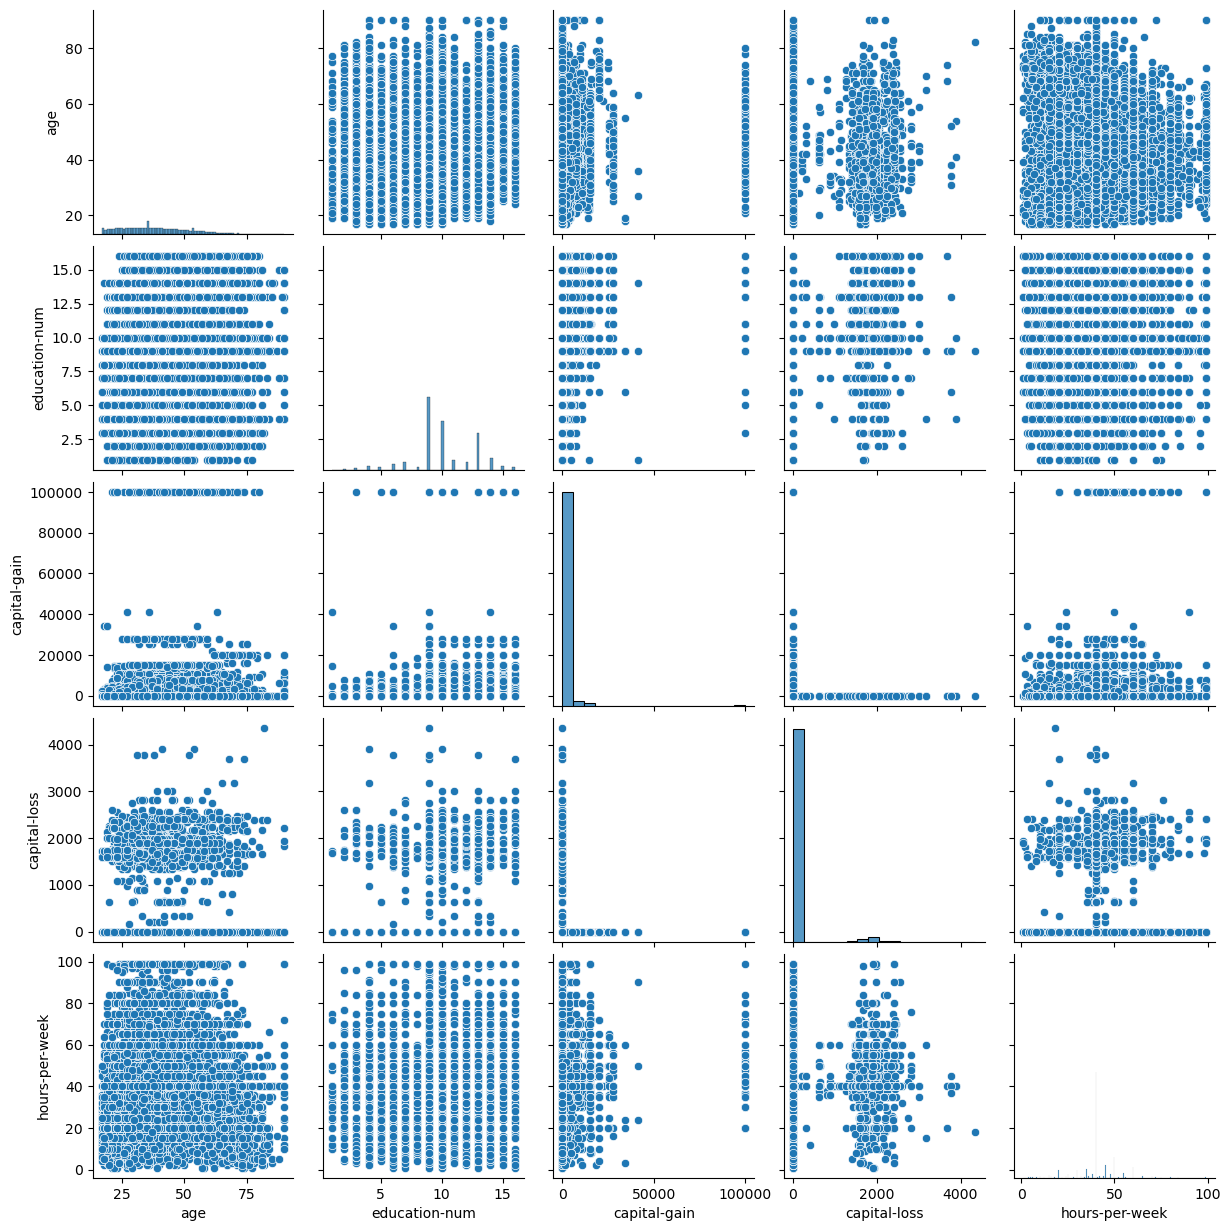

In [6]:
sns.pairplot(df)

In [7]:
df[df.duplicated()].shape[0]

5982

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df[df.duplicated()].shape[0]

0

### Preprocessing Assesment 
1) Age, Capital-loss,Capital-gain are skewed to the right.
2) hours-per-week has outliers.
3) All numeric features shoulde be normalized.
4) The target varaible should be mapped into 1 and 0.
5) All categorical features should be one-hot encoded.

In [10]:
df_skewed = ['age','capital-gain', 'capital-loss']

In [11]:
df_log = df[df_skewed].apply(lambda x: np.log(x+1))

In [12]:
df.drop(df_skewed, axis = 1, inplace = True)


In [13]:
df = pd.concat([df,df_log], axis = 1)

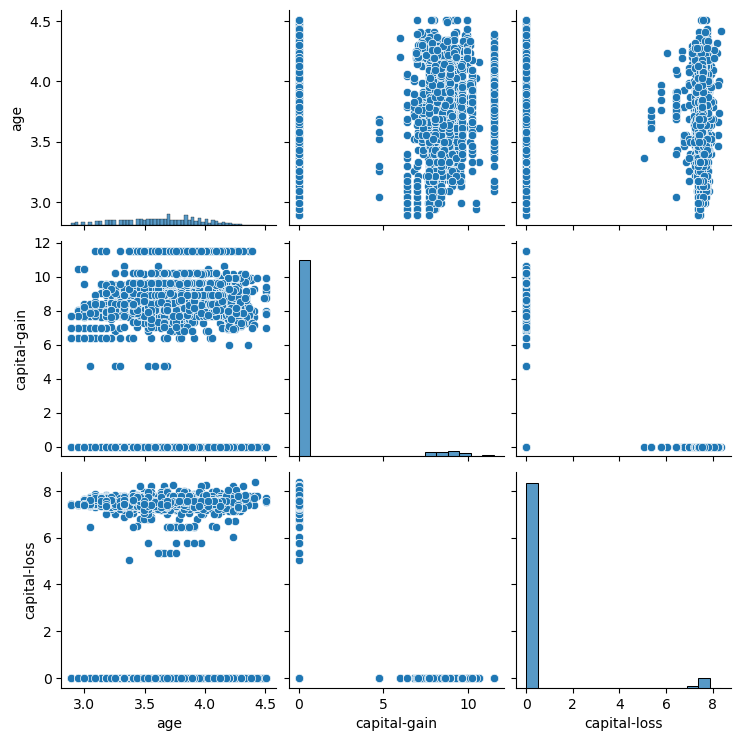

In [14]:
sns.pairplot(df_log)

In [15]:
#Prepoocessing 2nd phase
df['hours-per-week'].std()

12.45802079077719

In [16]:
df = df[df['hours-per-week'] <= df['hours-per-week'].mean() + 3*df['hours-per-week'].std() ]
df = df[df['hours-per-week'] >= df['hours-per-week'].mean() - 3*df['hours-per-week'].std() ]
df.shape[0]

38521

In [17]:
# Preprocessing 3rd phase: Normalization of all Numeric Features
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [18]:
# first initializing a Scaler by default 0 or 1
slr = MinMaxScaler()
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'] 


In [19]:

df[numerical] = slr.fit_transform(df[numerical])
df[numerical].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,38521.000000,38521.000000,38521.000000,38521.000000,38521.000000
mean,0.462518,0.609152,0.073224,0.048583,0.476754
std,0.207299,0.175475,0.227036,0.203055,0.155365
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.315230,0.533333,0.000000,0.000000,0.464789
50%,0.477134,0.600000,0.000000,0.000000,0.464789
75%,0.617992,0.800000,0.000000,0.000000,0.535211
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
#Preprocessing 4th phase:Target variable is 0 or 1 
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})
df.income.sample(10)

36231    0
21692    0
22298    0
23863    1
11486    0
17397    0
4062     0
8556     0
20373    0
28211    1
Name: income, dtype: int64

In [21]:
# Using One-Hot-Encoding
df = pd.get_dummies(df)
df.head()

,education-num,hours-per-week,income,age,capital-gain,capital-loss,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.800000,0.464789,0,0.492758,0.667492,0.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.800000,0.084507,0,0.642679,0.000000,0.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.533333,0.464789,0,0.477134,0.000000,0.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0.400000,0.464789,0,0.677952,0.000000,0.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0.800000,0.464789,0,0.294309,0.000000,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Split data into training & testing set
target = df.income
df.drop(['income'] , axis=1, inplace=True)
# Now train test split
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size = 0.3, random_state = 0)


In [24]:
# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 26964 samples.
Testing set has 11557 samples.


### Performance calculation of Naive Predictor

In [25]:
target.sum(),target.shape[0]

(9777, 38521)

In [26]:
# calculation of Accuracy,Precision and Recall
accuracy =  target.sum()/target.shape[0]
recall = target.sum()/target.sum()
precision = target.sum()/target.shape[0]

In [27]:
#F-Score Calculation for beta = 0.5 
f_score = (1+0.5**2)*(precision*recall)/(0.5**2*precision + recall)
AUC = 0.5

In [28]:
# Print the results 
print("Naive Predictor: [Accuracy score: {:.4f}, AUC: {:.4f}, F-Score: {:.4f}]".format(accuracy, AUC, f_score))

Naive Predictor: [Accuracy score: 0.2538, AUC: 0.5000, F-Score: 0.2983]


### Selecting Model

### Creating Training and  Predictive Pipeline
###### Importting fbeta score & Accuracy score

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score

from time import time

In [30]:
   
def predict_model(learner, sample_size, X_train, y_train, X_test, y_test):
    results = {}
       
    ### fit Learner to training data using 'sample_size' 
    ### Get start time
    start = time() 
    learner = learner.fit(X_train[:int(X_train.shape[0]*sample_size)], y_train[:int(X_train.shape[0]*sample_size)])

    ### Get end time
    end = time() 

    # Calculate the training time
    results['train_time'] = end - start

    # Get the predictions on the test set(X_test),
    # Get predictions on the first 300 training samples(X_train) using .predict()
    start = time()
    test_pred = learner.predict(X_test)
    train_pred = learner.predict(X_train[:300])
    end = time()

    # Calculate the total prediction time
    results['pred_time'] = end - start

    # Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300], train_pred)

    # Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test, test_pred)

    # Compute AUC on the the first 300 training samples using roc_auc_score()
    results['auc_train'] = roc_auc_score(y_train[:300], train_pred)

    # Compute AUC on the test set which is y_test
    results['auc_test'] = roc_auc_score(y_test, test_pred)

    # Print result
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
    # Return Result
    return results
    

### Prediction of Best Model

In [44]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

In [45]:
# Initializing the Three models
classifier_A = RandomForestClassifier(random_state = 42)
classifier_B = GradientBoostingClassifier(random_state = 42)
classifier_C = xgb.XGBClassifier(random_state =42)


# calculate the samples 1%, 10% & 100% of training data
samples_100 = len(y_train)

# To ensure the values are set as 'int' and not as 'float'
samples_10 = 0.1*len(y_train)
samples_1 = 0.01*len(y_train)

In [46]:
# Collect results on the learners
results = {}
for clf in [classifier_A, classifier_B, classifier_C]:
    classifier_name = clf.__class__.__name__
    results[classifier_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[classifier_name][i] = predict_model(clf, samples, X_train, y_train, X_test, y_test)

RandomForestClassifier trained on 269.64 samples.
RandomForestClassifier trained on 2696.4 samples.
RandomForestClassifier trained on 26964 samples.
GradientBoostingClassifier trained on 269.64 samples.
GradientBoostingClassifier trained on 2696.4 samples.
GradientBoostingClassifier trained on 26964 samples.
XGBClassifier trained on 269.64 samples.
XGBClassifier trained on 2696.4 samples.
XGBClassifier trained on 26964 samples.


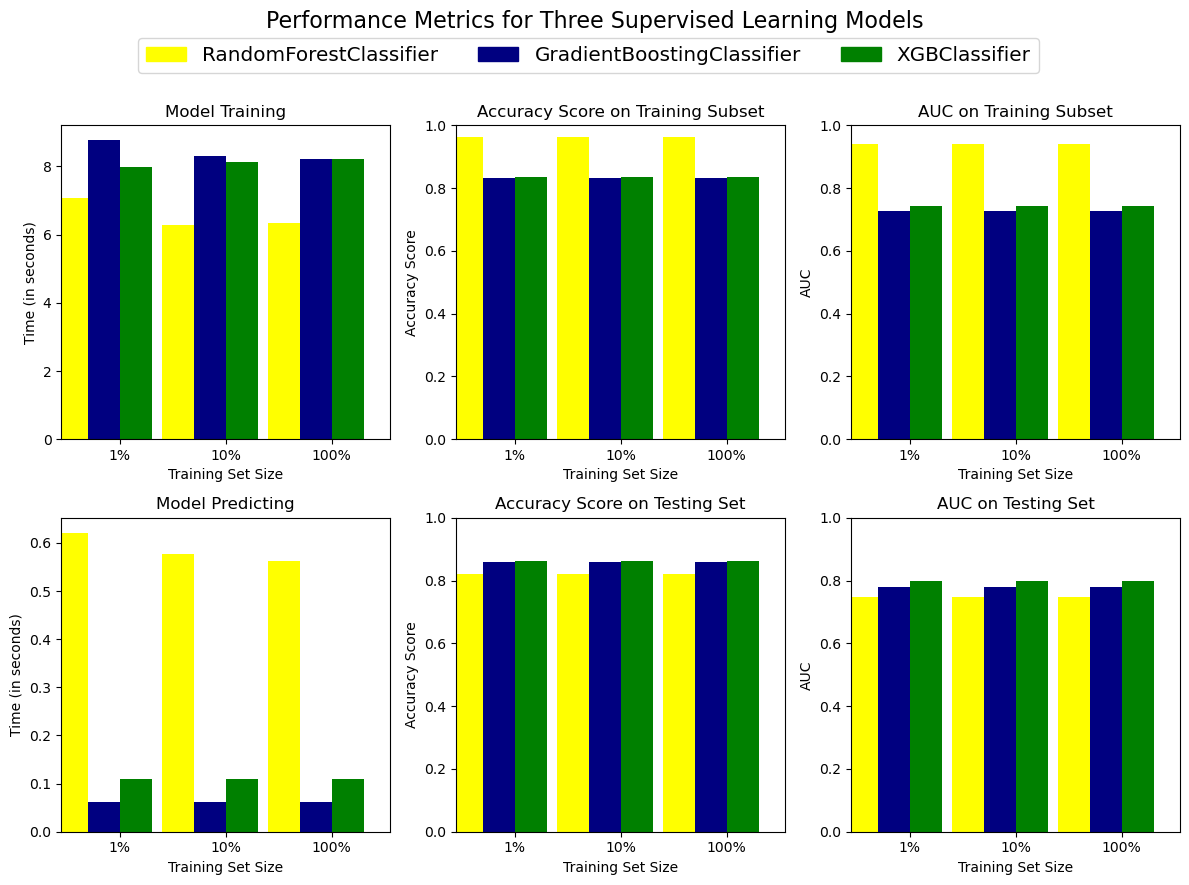

In [38]:
def evaluation(result):
    
    import matplotlib.patches as mpatches
    # Creating the figure using subplots
    fig, ax = plt.subplots(2,3, figsize = (12, 8))
    # Constants 
    bar_width = 0.3
    colors = ['yellow', 'navy', 'green']
    
    # Loop to plot panels
    for k, learner in enumerate(results.keys()):
        for j, metric in enumerate(['train_time', 'acc_train', 'auc_train', 'pred_time', 'acc_test', 'auc_test']):
            for i in np.arange(3):
                
                #Code of the plot
                ax[j//3, j%3].bar(i+k*bar_width, results[learner][i][metric], width = bar_width, color = colors[k])
                ax[j//3, j%3].set_xticks([0.45, 1.45, 2.45])
                ax[j//3, j%3].set_xticklabels(["1%", "10%", "100%"])
                ax[j//3, j%3].set_xlabel("Training Set Size")
                ax[j//3, j%3].set_xlim((-0.1, 3.0))
    
    # Add y- labels
    ax[0, 0].set_ylabel("Time (in seconds)")
    ax[0, 1].set_ylabel("Accuracy Score")
    ax[0, 2].set_ylabel("AUC")
    ax[1, 0].set_ylabel("Time (in seconds)")
    ax[1, 1].set_ylabel("Accuracy Score")
    ax[1, 2].set_ylabel("AUC")
    
    # Add titles
    ax[0, 0].set_title("Model Training")
    ax[0, 1].set_title("Accuracy Score on Training Subset")
    ax[0, 2].set_title("AUC on Training Subset")
    ax[1, 0].set_title("Model Predicting")
    ax[1, 1].set_title("Accuracy Score on Testing Set")
    ax[1, 2].set_title("AUC on Testing Set")

    # Set y-limits for score panels
    ax[0, 1].set_ylim((0, 1))
    ax[0, 2].set_ylim((0, 1))
    ax[1, 1].set_ylim((0, 1))
    ax[1, 2].set_ylim((0, 1))
    plt.tight_layout()
    # Create patches for the legend
    patches = []
    for i, learner in enumerate(results.keys()):
        patches.append(mpatches.Patch(color = colors[i], label = learner))
    plt.legend(handles = patches, bbox_to_anchor = (-.80, 2.53), \
               loc = 'upper center', borderaxespad = 0., ncol = 3, fontsize = 'x-large')
    
    # End result
    plt.suptitle("Performance Metrics for Three Supervised Learning Models", fontsize = 16, y = 1.10)
    plt.show()
evaluation(results)

### Best Model choosing : XGBoost

### Model Tuning


In [39]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

### Classifier initializing
clf =  xgb.XGBClassifier(random_state=42)

### Parameter list
parameters = {
    "learning_rate" : [0.1, 1],
    "n_estimators": [300, 400],
    'max_depth': [3, 5],
    'gamma' : [0.1, 0.3],
    'max_delta_step' : [1,3]
}

In [40]:
# Perform random search on the classifier using 'scorer' as the scoring method using GridSearchCV()
random_obj = RandomizedSearchCV(clf, parameters)

# Fit the random search object to the training data and find the optimal parameters using fit()
random_fit = random_obj.fit(X_train, y_train)

# Get the estimator

best_clf = random_fit.best_estimator_

#### Prediction with unoptimized model

In [41]:

acc_predictions = (clf.fit(X_train, y_train)).predict(X_test)
auc_predictions = (clf.fit(X_train, y_train)).predict_proba(X_test)[:,1]
acc_best_predictions = best_clf.predict(X_test)
auc_best_predictions = best_clf.predict_proba(X_test)[:,1]


In [42]:

print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, acc_predictions)))
print("AUC on testing data: {:.4f}".format(roc_auc_score(y_test, auc_predictions)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, acc_best_predictions)))
print("Final AUC on the testing data: {:.4f}".format(roc_auc_score(y_test, auc_best_predictions)))

Unoptimized model
------
Accuracy score on testing data: 0.8631
AUC on testing data: 0.9249

Optimized Model
------
Final accuracy score on the testing data: 0.8669
Final AUC on the testing data: 0.9269


#### Model Optimization

In [2]:
import xgboost as xgb
from xgboost import XGBClassifier

In [3]:
#from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,XGBClassifier 



#random_fit.best_estimator_
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0.3, 
              importance_type='gain', interaction_constraints='',
              learning_rate=0.1, max_delta_step=1, max_depth=5,
              min_child_weight=1, missing=None,monotone_constraints='()',
              n_estimators=300, n_jobs=4, num_parallel_tree=1,
              objective='binary:logistic', random_state=42, reg_alpha=0,
              reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=True,
              validate_parameters=1, verbosity=None)

ValueError: Label encoder was removed in 1.6.0.

In [4]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score


xg_clf = xgb.XGBClassifier(learning_rate = 0.1, 
                            n_estimators = 400, 
                           max_depth = 5,
                           gamma = 0.1,
                           max_delta_step = 1,
                            seed=42)

xg_clf.fit(X_train,y_train)
preds = xg_clf.predict(X_test)

NameError: name 'X_train' is not defined

In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, preds))
print("AUC: ", roc_auc_score(y_test, xg_clf.predict_proba(X_test)[:,1]))



In [ ]:

df_test = pd.read_csv('test_census.csv')
df_test.drop(['Unnamed: 0'] , axis=1, inplace=True)
categorical_var = []
for i in list(df.columns):
    if i not in ['education-num', 'hours-per-week','age','capital-gain','capital-loss']:
        categorical_var.append(i)
# Log-transform the skewed features
skewed = ['age','capital-gain', 'capital-loss']

df_log = df_test[skewed].apply(lambda x: np.log(x + 1))

df_test.drop(skewed , axis=1, inplace=True)

df_test = pd.concat([df_test, df_log], axis=1)

In [ ]:
# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

df_test[numerical] = scaler.fit_transform(df_test[numerical])

# fill missing values for numeric variables with approximatelly gaussian dictribution:
for col in ['age', 'education-num', 'hours-per-week']:
    df_test[col]= df_test[col].fillna(df[col].mean())

In [ ]:
# fill missing values for numeric variables with skewed dictribution:
for col in ['capital-gain', 'capital-loss']:
    df_test[col]= df_test[col].fillna(df[col].median())

#fill missing categorical values with most freaquent category in training data:
#load data
og_df = pd.read_csv('census.csv')

for col in categorical_var:
    if col in list(df_test.columns):
        df_test[col]= df_test[col].fillna(og_df.groupby([col])[col].count().sort_values(ascending=False).index[0])
        
df_test = pd.get_dummies(df_test)
xg_preds = xg_clf.predict_proba(df_test)[:, 1]
final = pd.DataFrame(list(xg_preds), columns = ['income'])
final = final.reset_index()
final.rename(columns={"index":"id"}, inplace = True)
final.head()